# 📊 Term Deposit Subscription Prediction

## 📌 Objective
Predict whether a bank customer will subscribe to a term deposit based on marketing campaign data.

## 📂 Dataset
Bank Marketing Dataset (UCI)

## 🎯 Problem Type
Binary Classification

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [8]:
# Load dataset
df = pd.read_csv(r"D:\\Intrenship Assingment_2\\bank.csv")

# Show first rows
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


 🔍 Exploratory Data Analysis (EDA)

In this section, we analyze the structure and distribution of the dataset to gain meaningful insights.

Key steps include:
- Understanding feature types
- Checking for missing values
- Analyzing the distribution of the target variable

This helps in identifying patterns and potential challenges such as class imbalance.

In [10]:

# Dataset shape
df.shape

# Info
df.info()

# Check null values
df.isnull().sum()

# Target distribution
df['deposit'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


deposit
no     5873
yes    5289
Name: count, dtype: int64

## 📊 Data Visualization
Understanding the distribution of the target variable and key features.

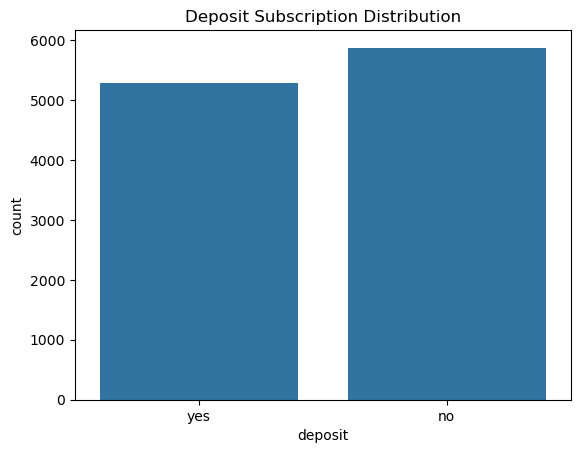

In [11]:
# Target distribution
sns.countplot(x='deposit', data=df)
plt.title("Deposit Subscription Distribution")
plt.show()

- The dataset may be imbalanced (more 'no' than 'yes').
- This can affect model performance.

## ⚙️ Data Preprocessing
Encoding categorical variables and preparing data for modeling.

In [12]:
# Convert target to binary
df['deposit'] = df['deposit'].map({'yes':1, 'no':0})

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

- Label Encoding is used for simplicity.
- In real-world projects, One-Hot Encoding is often preferred.

## ✂️ Train-Test Split
Splitting data into training and testing sets.

In [14]:
# Features and target
X = df.drop('deposit', axis=1)
y = df['deposit']

# Split data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Check shapes
X_train.shape, X_test.shape

((8929, 16), (2233, 16))

## 🤖 Model Training
Training Logistic Regression and Random Forest models.

In [15]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

## 📊 Model Evaluation
Evaluating models using confusion matrix and classification report.

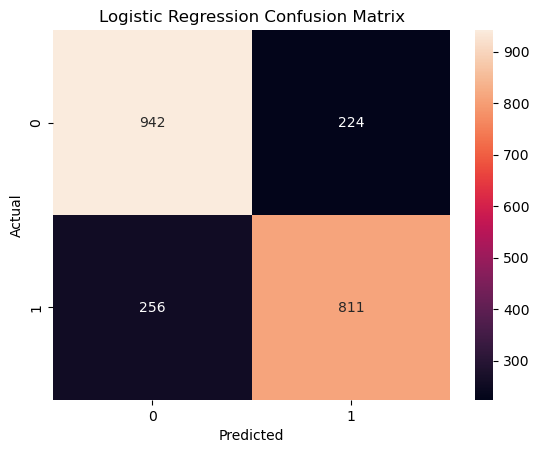

In [17]:
from sklearn.metrics import confusion_matrix

# Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm_lr, annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [18]:
from sklearn.metrics import classification_report

print("🔹 Logistic Regression:\n")
print(classification_report(y_test, y_pred_lr))

print("🔹 Random Forest:\n")
print(classification_report(y_test, y_pred_rf))

🔹 Logistic Regression:

              precision    recall  f1-score   support

           0       0.79      0.81      0.80      1166
           1       0.78      0.76      0.77      1067

    accuracy                           0.79      2233
   macro avg       0.78      0.78      0.78      2233
weighted avg       0.79      0.79      0.78      2233

🔹 Random Forest:

              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1166
           1       0.81      0.85      0.83      1067

    accuracy                           0.83      2233
   macro avg       0.83      0.83      0.83      2233
weighted avg       0.83      0.83      0.83      2233



## 📉 ROC Curve
Evaluating model performance using AUC score.

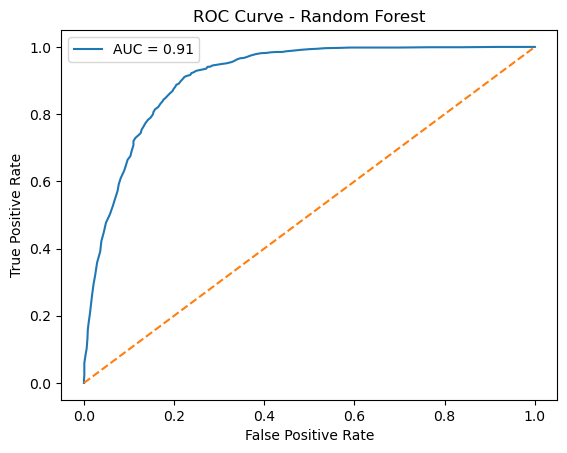

In [19]:
from sklearn.metrics import roc_curve, auc

# Probabilities
y_prob = rf.predict_proba(X_test)[:,1]

# ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

## 🧠 Feature Importance
Understanding which features impact predictions the most.

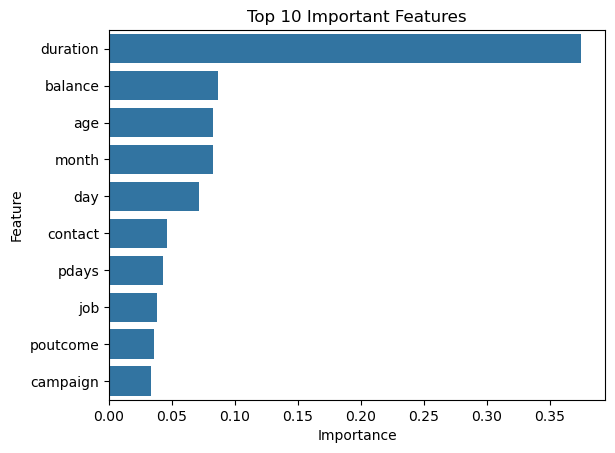

In [20]:
# Feature importance
importances = rf.feature_importances_
features = X.columns

feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
sns.barplot(x='Importance', y='Feature', data=feat_imp.head(10))
plt.title("Top 10 Important Features")
plt.show()

## ✅ Conclusion

- Random Forest outperformed Logistic Regression.
- Key features influencing predictions include:
  - Duration
  - Balance
  - Age
- The model can help banks target customers more effectively.